# Exploratory Data Analysis

This notebook will explore the image dataset and gauge the quality of data that we're working with. 

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
# File paths
BASE_DIR = Path.cwd()

while not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

train = BASE_DIR / "data" / "Train"
test = BASE_DIR / "data" / "Test"

First, let's look at a sample of our images. Most of the classes in this dataset are visually similar. This is especially problematic given the resembalance of melanoma to other classes like nevus or pigmented benign keratosis. There are also several artifacts that will need to be removed such as hair follicles and edges of the dermoscopic lens.

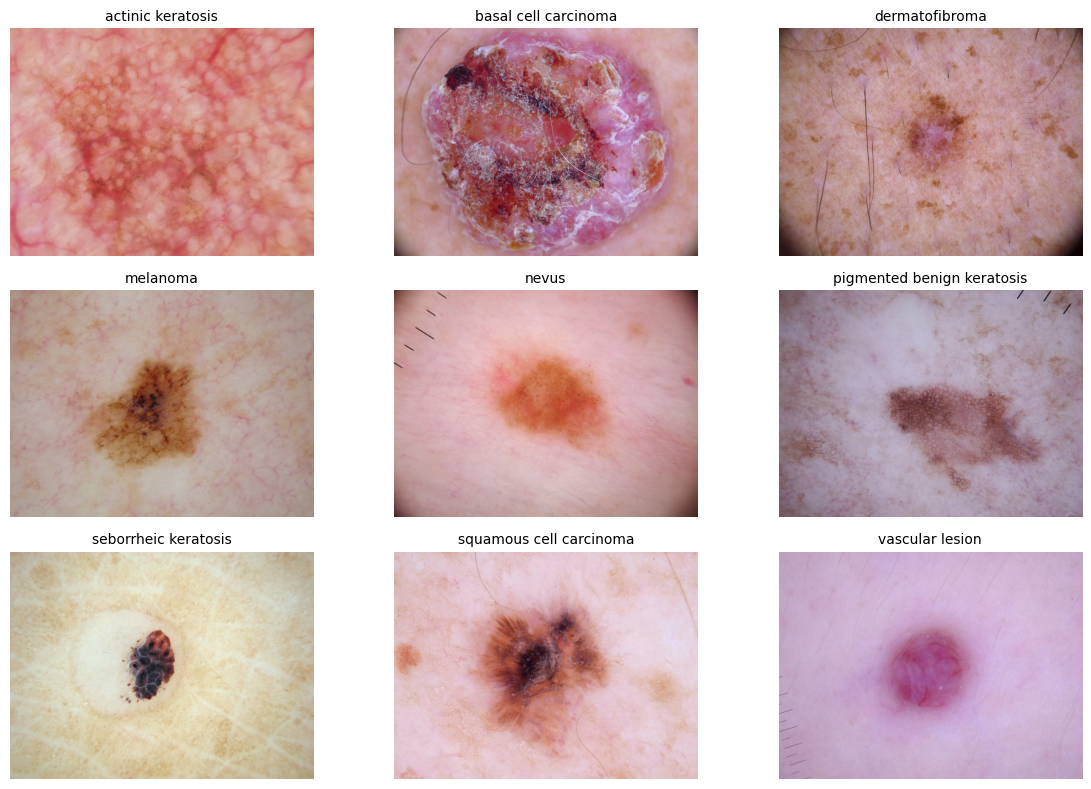

In [7]:
classes = sorted(os.listdir(train))

images = []

# collect 1 image per class
for cls in classes:
    class_path = os.path.join(train, cls)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(class_path, file)
            images.append((cls, img_path))
            break  # only take 1 image per class

# plot
n = len(images)
cols = 3
rows = (n + cols - 1) // cols

plt.figure(figsize=(12, 8))

for i, (cls, img_path) in enumerate(images):
    img = Image.open(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(cls, fontsize=10)
    plt.axis("off")

plt.tight_layout()

Plotting the image sizes, we can see that the image sizes vary heavily in the dataset. Interestingly, most of the train images are less than (3000x2500), but a a large portion of the test set clusters around (6000x4500). Resizing the images directly will lead to distortion, so we need to scale the images to preserve their aspect ratio before cropping to 224x224.

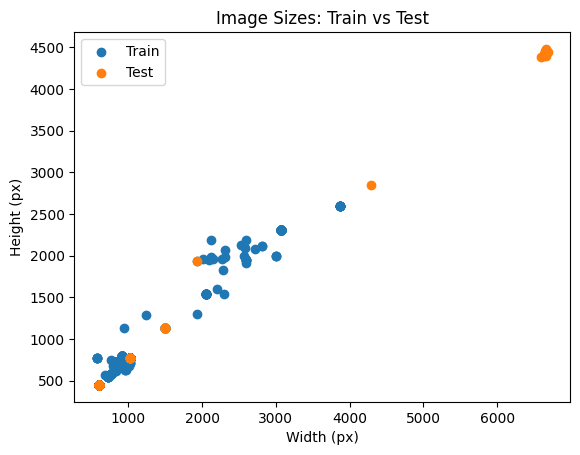

In [3]:
train_h, train_w = [], []
test_h, test_w = [], []

# Train images
for root, dirs, files in os.walk(train):
    for file in files:
        try:
            with Image.open(os.path.join(root, file)) as img:
                w, h = img.size
                train_w.append(w)
                train_h.append(h)
        except:
            pass

# Test images
for root, dirs, files in os.walk(test):
    for file in files:
        try:
            with Image.open(os.path.join(root, file)) as img:
                w, h = img.size
                test_w.append(w)
                test_h.append(h)
        except:
            pass

# Plot
plt.scatter(train_w, train_h, label="Train")
plt.scatter(test_w, test_h, label="Test")

plt.title("Image Sizes: Train vs Test")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.legend()
plt.show()

Calculating the average image size, we see the only classes that differ are pigmented keratosis, nevus, and melanoma.

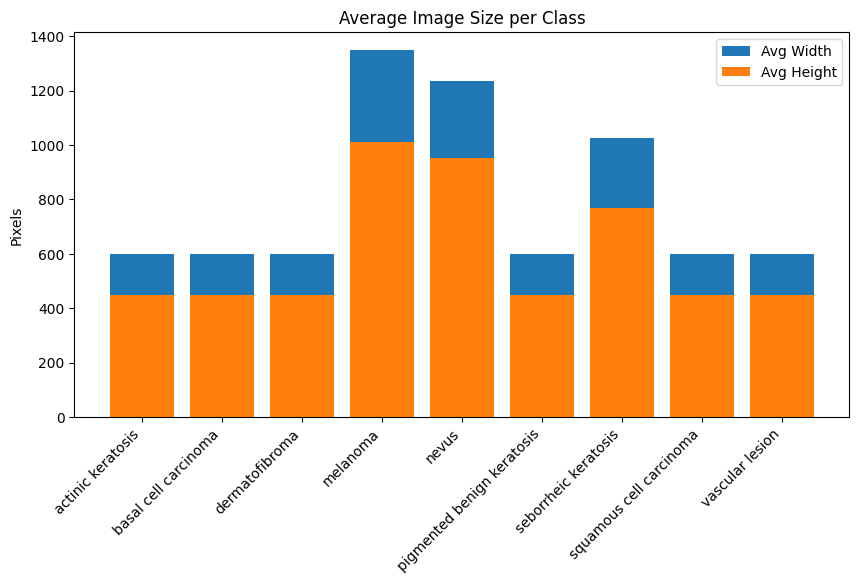

In [4]:
class_stats = {}

# Count files
for root, dirs, files in os.walk(train):
    for file in files:
        try:
            path = os.path.join(root, file)

            class_name = os.path.basename(os.path.dirname(path))

            with Image.open(path) as img:
                w, h = img.size

                if class_name not in class_stats:
                    class_stats[class_name] = {"widths": [], "heights": []}

                class_stats[class_name]["widths"].append(w)
                class_stats[class_name]["heights"].append(h)

        except:
            pass

# Build dataframe 
rows = []
for cls, vals in class_stats.items():
    rows.append({
        "class": cls,
        "avg_width": np.mean(vals["widths"]),
        "avg_height": np.mean(vals["heights"]),
        "count": len(vals["widths"])
    })

df = pd.DataFrame(rows).sort_values("class")

# Plot
plt.figure(figsize=(10,5))
plt.bar(df["class"], df["avg_width"], label="Avg Width")
plt.bar(df["class"], df["avg_height"], bottom=df["avg_width"]*0, label="Avg Height")
plt.ylabel("Pixels")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.title("Average Image Size per Class")
plt.show()

We can see we have a heavily imbalanced dataset. The smallest class, Seborrheic Keratosis, has less than 100 images. The largest class, Pigmented Benign Keratosis, has over 400. 

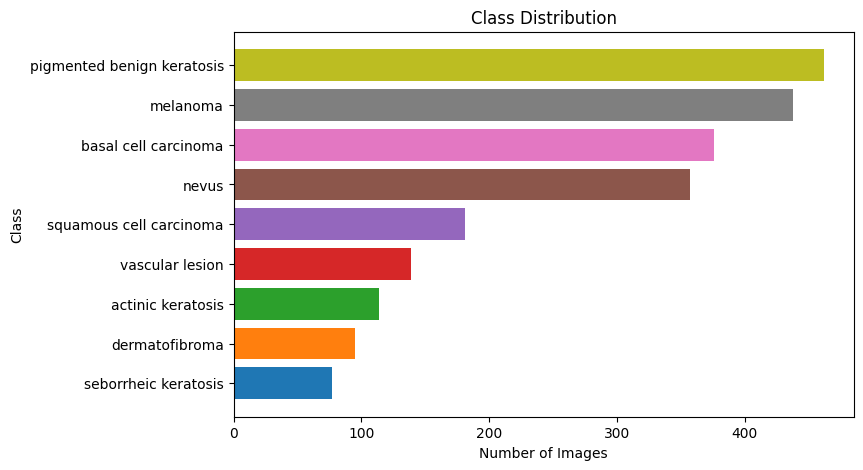

In [5]:
# Distribution of images
df_sorted = df.sort_values("count")
colors = plt.cm.tab10(np.arange(len(df)))

plt.figure(figsize=(8,5))
plt.barh(df_sorted["class"], df_sorted["count"], color=colors)

plt.title("Class Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.show()